In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [4]:
class batsmanstate(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [27]:
def cal_sr(state: batsmanstate) -> batsmanstate:
    sr = (state['runs']/state['balls'])*100
    # state['sr'] = sr
    
    return {'sr': sr}

In [15]:
def cal_bpb(state: batsmanstate) -> batsmanstate:
    
    bpb = state['balls']/(state['fours'] + state['sixes'])
    # state['bpb'] = bpb
    return {'bpb': bpb}

In [16]:
def cal_b_p(state: batsmanstate) -> batsmanstate:
    boundary_percentage = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
    # state['boundary_percentage'] = boundary_percentage
    
    return {'boundary_percentage': boundary_percentage}

In [22]:
def gen_summary(state: batsmanstate) -> batsmanstate:
    summary = f"""
    strike rate = {state['sr']} \n
    balls per boundary = {state['bpb']} \n
    boundary percentage = {state['boundary_percentage']} \n
    """
    # state['summary'] = summary
    
    return {'summary': summary}

In [28]:
# creating the graph
graph = StateGraph(batsmanstate)

# nodes
graph.add_node("calculating_sr", cal_sr)
graph.add_node("calculating_bpb", cal_bpb)
graph.add_node("calculating_boundary_percentage", cal_b_p)
graph.add_node("generate_summary", gen_summary)

# edges
graph.add_edge(START, "calculating_sr")
graph.add_edge(START, "calculating_bpb")
graph.add_edge(START, "calculating_boundary_percentage")

graph.add_edge("calculating_sr", "generate_summary")
graph.add_edge("calculating_bpb", "generate_summary")
graph.add_edge("calculating_boundary_percentage", "generate_summary")

graph.add_edge("generate_summary", END)


# compile
workflow = graph.compile()

In [29]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

output_state = workflow.invoke(initial_state)

In [30]:
print(output_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percentage': 48.0, 'summary': '\n    strike rate = 200.0 \n\n    balls per boundary = 5.0 \n\n    boundary percentage = 48.0 \n\n    '}


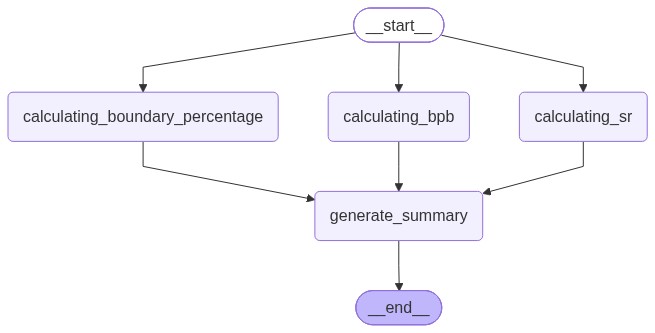

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

